In [1]:
import pandas as pd
import os

In [2]:
y_train = pd.read_csv('Datasets/y_train.csv')
y_test = pd.read_csv('Datasets/y_test.csv')
names = ["train", "test"]
train_sets = [y_train, y_test]

In [3]:
y_train.head()

,alien point of view,belonging,father and son,friendship,human vs. captivity,husband and wife,infatuation,obsession,romantic love,time travel
0,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,1,0
3,1,0,0,1,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,1


In [4]:
#Create a dictionary to store all columns we want to test
theme_groups = {
    #Sci-Fi Themes
    "science_fiction": ["alien point of view", "time travel", "human vs. captivity"],
    
    #Relationships
    "family_relationships": ["father and son", "husband and wife"],
    "friendships": ["friendship", "belonging"],
    "romantic_relationships": ["romantic love", "infatuation", "obsession", "husband and wife"],
    
    #Psychological
    "psychological": ["infatuation", "obsession"],
    "existential": ["belonging", "human vs. captivity"],
    
    #Mixed Categories
    "love_and_psychology": ["romantic love", "infatuation", "obsession", "belonging"],

    #We can add custom combinations that make sense
}

In [5]:
base_folder = "archysets"
os.makedirs(base_folder, exist_ok=True)

In [6]:
for i in range(len(train_sets)):
    for label, themes in theme_groups.items():
        y_copy = train_sets[i].copy()

        #Get the maximum value (if 1 is present, obviously the parent theme is present)
        y_copy[label] = y_copy[themes].max(axis=1)

        y_copy = y_copy.drop(columns=themes)

        #Give corresponding name, and store in seperate folder
        file_path = os.path.join(base_folder, f"{names[i]}_{label}_dataset.csv")
        y_copy.to_csv(file_path, index=False)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#XGboost

In [8]:
#Load fixed X_train and X_test
X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
X_test = pd.read_csv('Datasets/cleaned_X_test2.csv')

#Standardize X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Dictionary to store accuracy results
accuracy_results = {}

#Define the folder where y_train and y_test versions are stored
archysets_folder = "archysets"

#Loop over all versions of y_train and y_test in the folder
for y_file in os.listdir(archysets_folder):
    if "train" in y_file:
        dataset_name = y_file.replace("train_", "").replace(".csv", "")
        y_train_path = os.path.join(archysets_folder, y_file)
        y_test_path = os.path.join(archysets_folder, y_file.replace("train", "test"))

        if not os.path.exists(y_test_path):
            print(f"{y_file} Missing")
            continue

        #Load y_train and y_test
        y_train = pd.read_csv(y_train_path)
        y_test = pd.read_csv(y_test_path)

        #Convert multi-labels to single-label classification using idxmax
        y_train = y_train.idxmax(axis=1)
        y_test = y_test.idxmax(axis=1)

        #Encode labels
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_test_encoded = label_encoder.transform(y_test)

        #Apply SMOTE to balance classes
        smote = SMOTE(random_state=42)
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train_encoded)

        """#Apply PCA (keeps 20% variance)
        pca = PCA(n_components=0.2)
        X_train_pca = pca.fit_transform(X_train_balanced)
        X_test_pca = pca.transform(X_test_scaled)"""

        #Split into train and validation sets
        X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_balanced, y_train_balanced, test_size=0.2, random_state=42)

        #Train XGBoost model
        xgb_model = XGBClassifier(random_state=42, objective='multi:softmax', num_class=len(np.unique(y_train_encoded)), early_stopping_rounds=10)
        xgb_model.fit(X_train_final, y_train_final, eval_set=[(X_val, y_val)], verbose=False)

        #Predict and evaluate on validation set
        y_pred = xgb_model.predict(X_val)
        val_accuracy = accuracy_score(y_val, y_pred)

        #Predict and evaluate on test set
        y_test_pred = xgb_model.predict(X_test_scaled)
        test_accuracy = accuracy_score(y_test_encoded, y_test_pred)

        #Store accuracy results
        accuracy_results[dataset_name] = test_accuracy
        print(f"Accuracy for {dataset_name}: {test_accuracy:.4f}")

Accuracy for existential_dataset: 0.0990
Accuracy for family_relationships_dataset: 0.1089
Accuracy for friendships_dataset: 0.1386
Accuracy for love_and_psychology_dataset: 0.2475
Accuracy for psychological_dataset: 0.1485
Accuracy for romantic_relationships_dataset: 0.2673
Accuracy for science_fiction_dataset: 0.1881


In [9]:
#Sort results by accuracy
sorted_results = dict(sorted(accuracy_results.items(), key=lambda item: item[1], reverse=True))

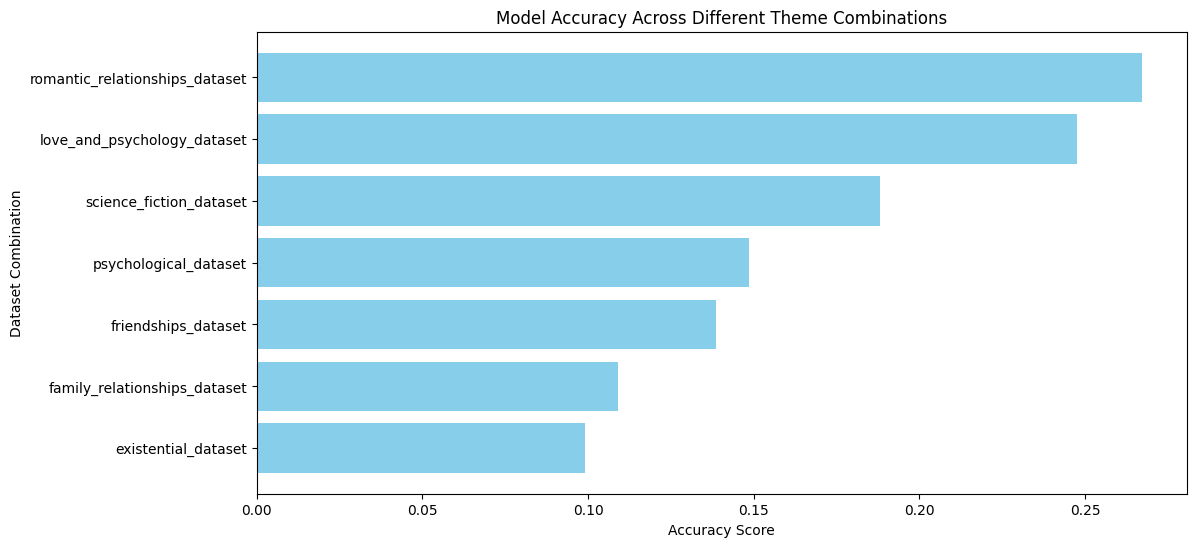

In [10]:
#Plot accuracy results
plt.figure(figsize=(12, 6))
plt.barh(list(sorted_results.keys()), list(sorted_results.values()), color='skyblue')
plt.xlabel("Accuracy Score")
plt.ylabel("Dataset Combination")
plt.title("Model Accuracy Across Different Theme Combinations")
plt.gca().invert_yaxis()
plt.show()

In [11]:
print(accuracy_results)

{'existential_dataset': 0.09900990099009901, 'family_relationships_dataset': 0.10891089108910891, 'friendships_dataset': 0.13861386138613863, 'love_and_psychology_dataset': 0.24752475247524752, 'psychological_dataset': 0.1485148514851485, 'romantic_relationships_dataset': 0.26732673267326734, 'science_fiction_dataset': 0.18811881188118812}


In [12]:
print(os.listdir("archysets"))

['.ipynb_checkpoints', 'test_existential_dataset.csv', 'test_family_relationships_dataset.csv', 'test_friendships_dataset.csv', 'test_love_and_psychology_dataset.csv', 'test_psychological_dataset.csv', 'test_romantic_relationships_dataset.csv', 'test_science_fiction_dataset.csv', 'train_existential_dataset.csv', 'train_family_relationships_dataset.csv', 'train_friendships_dataset.csv', 'train_love_and_psychology_dataset.csv', 'train_psychological_dataset.csv', 'train_romantic_relationships_dataset.csv', 'train_science_fiction_dataset.csv']


In [13]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
label_encoder = LabelEncoder()

# To store the accuracy results
accuracy_results = {}

# Iterate over the files again
for y_file in os.listdir(archysets_folder):
    if "train" in y_file:
        #Load files
        y_train_file = os.path.join(archysets_folder, y_file)
        y_train = pd.read_csv(y_train_file)

        #Get corresponding test file
        y_test_file = y_train_file.replace('train', 'test')
        y_test = pd.read_csv(y_test_file)

        #Set the labels to a single column
        y_train = y_train.idxmax(axis=1)
        y_test = y_test.idxmax(axis=1)

        #Encode the labels
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_test_encoded = label_encoder.transform(y_test)
   
        #Define pipeline
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.76)),
            ('oversampler', RandomOverSampler(random_state=42)),
            ('logreg', LogisticRegressionCV(cv=3, max_iter=1000, multi_class='ovr', solver='liblinear', n_jobs=-1, class_weight='balanced'))
        ])

        #Define the parameter for grid search
        param_grid = {
            'logreg__Cs': [0.1, 1, 10],
            'logreg__max_iter': [1000],
            'logreg__solver': ['liblinear'],
        }

        grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

        #Train the model
        grid_search.fit(X_train, y_train_encoded)

        #Get the best model
        best_model = grid_search.best_estimator_

        #Predict on train set
        y_train_pred = best_model.predict(X_train)
        train_accuracy = accuracy_score(y_train_encoded, y_train_pred)

        #Predict on test set
        y_test_pred = best_model.predict(X_test)
        test_accuracy = accuracy_score(y_test_encoded, y_test_pred)

        #Store the results in accuracy_results
        accuracy_results[f"{y_file}"] = {
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'best_params': grid_search.best_params_
        }

        # Print the results
        print(f"Results for {y_file}:")
        print(f"Train Accuracy: {train_accuracy:.3f}")
        print(f"Test Accuracy: {test_accuracy:.3f}")
        print("Best Parameters:", grid_search.best_params_)

# Sort and print
sorted_results = dict(sorted(accuracy_results.items(), key=lambda item: item[1]['test_accuracy'], reverse=True))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Results for train_existential_dataset.csv:
Train Accuracy: 0.371
Test Accuracy: 0.158
Best Parameters: {'logreg__Cs': 1, 'logreg__max_iter': 1000, 'logreg__solver': 'liblinear'}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Results for train_family_relationships_dataset.csv:
Train Accuracy: 0.411
Test Accuracy: 0.208
Best Parameters: {'logreg__Cs': 1, 'logreg__max_iter': 1000, 'logreg__solver': 'liblinear'}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Results for train_friendships_dataset.csv:
Train Accuracy: 0.379
Test Accuracy: 0.129
Best Parameters: {'logreg__Cs': 1, 'logreg__max_iter': 1000, 'logreg__solver': 'liblinear'}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Results for train_love_and_psychology_dataset.csv:
Train Accuracy: 0.403
Test Accuracy: 0.149
Best Parameters: {'logreg__Cs': 1, 'logreg__max_iter': 1000, 'logreg__solver': 'liblinear'}
Fitting 3 folds for each of 3 candi

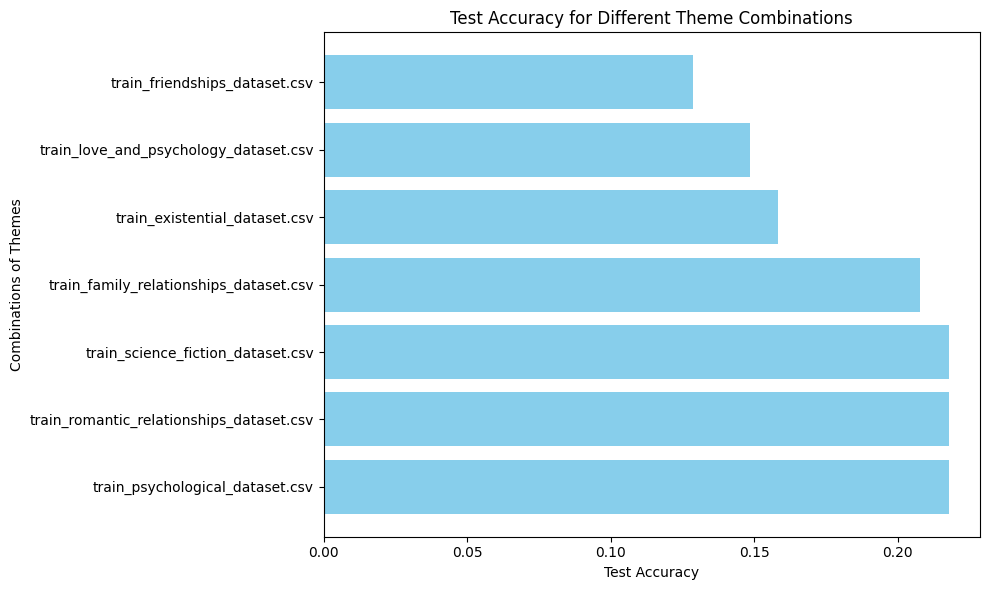

In [16]:
#Sort the results by test accuracy in descending order
sorted_results = dict(sorted(accuracy_results.items(), key=lambda item: item[1]['test_accuracy'], reverse=True))

#Extract the combinations and corresponding accuracies
combinations = list(sorted_results.keys())
test_accuracies = [results['test_accuracy'] for results in sorted_results.values()]

plt.figure(figsize=(10, 6))
plt.barh(combinations, test_accuracies, color='skyblue')

plt.xlabel('Test Accuracy')
plt.ylabel('Combinations of Themes')
plt.title('Test Accuracy for Different Theme Combinations')

plt.tight_layout()
plt.show()